In [54]:
#NEW
#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PIXE_Intensities.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
import scipy as sp
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PIXE_Intensities.ipynb started: Mon, 30 Mar 2026 11:43:06
INFO: SETUP COMPLETE (0.00 ms)
---------------------------------------


In [25]:
def Kb1_Ka1_perElement(element:str, K_n:list, K_add:list, Kb1_Ka1:dict, Kb1_Ka1_err:dict, K_scatter:list, K_x_index:list):
    DPI = 300
    plt.figure(figsize=(5,3), dpi=DPI)
    data = Kb1_Ka1[element]
    errors = Kb1_Ka1_err[element]
    
    plt.title(f'{element} - $K_\\beta/K_\\alpha$ ratio')
    plt.ylabel(r'$K_{\beta}/K_{\alpha}$')
    
    plt.ylim(0.6*np.max(data),1.1*np.max(data))
    # plt.grid(axis='y', color='black', linestyle=':', linewidth=0.4, alpha=0.2, zorder=0)
    plt.xticks([])
    
    plt.fill_between(x=[-0.1,0.5], y1=0, y2=1, color=color_schemes['c_light'][5], alpha=0.5, zorder=1)
    plt.fill_between(x=[0.7,1.3], y1=0, y2=1, color=color_schemes['c_light'][0], alpha=0.5, zorder=1)
    plt.fill_between(x=[1.5,2.1], y1=0, y2=1, color=color_schemes['c_light'][4], alpha=0.5, zorder=1)
    plt.fill_between(x=[2.3,2.5], y1=0, y2=1, color=color_schemes['c_light'][2], alpha=0.5, zorder=1)
    
    plt.text(0.2, 1.07*np.max(data), 'Measurement', fontsize=8, color='black', ha='center', va='center', zorder=2)
    plt.text(1.0, 1.07*np.max(data), 'Theory', fontsize=8, color='black', ha='center', va='center', zorder=2)
    plt.text(1.8, 1.07*np.max(data), 'Experiment', fontsize=8, color='black', ha='center', va='center', zorder=2)
    plt.text(2.4, 1.07*np.max(data), 'Fitted', fontsize=8, color='black', ha='center', va='center', zorder=2)
    
    for i in range(len(data)):
        if (data[i] != -1):
            plt.errorbar(x=K_x_index[i],y=data[i],yerr=errors[i],markersize=3,capsize=2,fmt='',lw=0,elinewidth=0.6,ecolor='black',color='black',marker=K_scatter[i], zorder=3)
            
            if (i == 0):
                plt.text(1.6, data[0]-0.01, K_n[0], rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 1):
                plt.text(2.4, data[1]-0.01, K_n[1], rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 2):
                plt.text(0.8, data[2]-0.005, f'{K_n[2]} \n {K_add[2]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 3):
                plt.text(1.2, data[3]-0.015, f'{K_n[3]} \n {K_add[3]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 4):
                plt.text(1.0, data[4]-0.005, f'{K_n[4]} \n {K_add[4]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 5):
                plt.text(1.8, data[5]-0.01, f'{K_n[5]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 6):
                plt.text(2.0, data[6]-(data[6]*0.12), f'{K_n[6]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
                
                
            if (K_scatter[i] == 'x'):
                plt.scatter([],[],s=8,lw=1,marker=K_scatter[i],color='black',label=f'{K_n[i]} \n {K_add[i]}')
            else:
                plt.scatter([],[],s=8,lw=0.5,marker=K_scatter[i],color='black',label=f'{K_n[i]} \n {K_add[i]}')
    
    plt.tight_layout()
    plt.savefig(f'./intensities/{element}_Kb1_Ka1.png', dpi=DPI)
    plt.savefig(f'./intensities/{element}_Kb1_Ka1.pdf', dpi=DPI)
    plt.show()

In [58]:
def self_absorption_correction(element, incident_angle, emergent_angle, thickness, incident_energy, emitted_energy):
    '''
    Inputs:\n
    element: str, chemical symbol of the element (e.g., 'Cu')\n
    incident_angle: float, angle of the incident X-ray beam in degrees\n
    emergent_angle: float, angle of the emitted X-ray beam in degrees\n
    thickness: float, thickness of the sample in cm\n
    incident_energy: float, energy of the incident X-ray in eV\n
    emitted_energy: float, energy of the emitted X-ray in eV\n
    
    Returns:\n
    correction_factor: float, the self-absorption correction factor to be applied to the measured intensity
    
    Formula:\n
    Ertugral et al. (2007)
    '''
    if (incident_angle > 0):
        mu_inc = xraydb.mu_elam(element, energy=incident_energy)
        a = mu_inc / sp.special.sindg(incident_angle)
    else:
        mu_inc = 0
        a = 0
    
    mu_em = xraydb.mu_elam(element, energy=emitted_energy)
    
    b = mu_em / sp.special.sindg(emergent_angle)
    A = 1 - np.exp(-(a+b)*thickness)
    B = (a+b)*thickness
    return A/B


In [ ]:
# AIR ABSORPTION
from xraydb import material_mu

energy = np.linspace(1000, 41000, 201)

mu = material_mu('H2O', energy)

# mu is returned in 1/cm
trans = np.exp(-0.1 * mu)

plt.plot(energy, trans, label='transmitted')
plt.plot(energy, 1-trans, label='attenuated')
plt.title('X-ray absorption by 1 mm of water')
plt.xlabel('Energy (eV)')
plt.ylabel('Transmitted / Attenuated fraction')
plt.legend()
plt.show()

In [66]:
df = pd.read_csv('measured_Lines_database.csv', sep=',', header=0)

def Kb1_Ka1_fromData(df,elem:str,MCA:int,EG:int,Set:str):
    '''
    Inputs:\n
    df: DataFrame containing the measured lines data\n
    elem: Element for which the Kb1/Ka1 ratio should be calculated\n
    MCA: Value of MCA setting\n
    EG: Value of EG setting\n
    Set: Name of the measurement set, letters only (e.g. 'A', 'B', 'C', 'D')
    '''
    
    Amersham_dict = {'thickness': 0.01, 'incident_angle': 0, 'emergent_angle': 90, 'emitted_energy_Ka1': xraydb.xray_lines(elem, 'K')['Ka1'][0], 'emitted_energy_Kb1': xraydb.xray_lines(elem, 'K')['Kb1'][0]}
    # Mini_X_dict = {'thickness': 0.0, 'incident_angle': 0, 'emergent_angle': 90, 'emitted_energy_Ka1': xraydb.xray_energy(elem, 'Ka1'), 'emitted_energy_Kb1': xraydb.xray_energy(elem, 'Kb1')}
    
    if (Set == 'A'):
        Set = 'Mini-X Set A'
    elif (Set == 'B'):
        Set = 'PIXE Amersham Source Set B'
    elif (Set == 'C'):
        Set = 'PIXE Amersham Source Set C'
    elif (Set == 'D'):
        Set = 'PIXE Amersham Source Set D'
    
    lines_data = {}
    lines_selection = ['Kb1','Ka1']
    for line in lines_selection:
        for i in range(len(df)):
            if ((df.loc[i,'element'] == elem) and (df.loc[i,'line_name'] == line) and (df.loc[i,'total_mca'] == MCA) and (df.loc[i,'energy_gain'] == EG) and (df.loc[i,'measurement_type'] == Set)):
                m_list = df.loc[i,:].values.tolist()
                param = [m_list[6], m_list[7], m_list[8]]
                param_min = [m_list[6]-m_list[9], m_list[7]-m_list[10], m_list[8]-m_list[11]]
                param_max = [m_list[6]+m_list[9], m_list[7]+m_list[10], m_list[8]+m_list[11]]
                x_lin = np.linspace(m_list[7]-3*m_list[8], m_list[7]+3*m_list[8], 1000)
                lines_data[line] = [np.sum(gauss_func(param, x_lin)), np.sum(gauss_func(param_min, x_lin)), np.sum(gauss_func(param_max, x_lin))]
                
    fit_val = lines_data['Kb1'][0]/lines_data['Ka1'][0]
    fit_min_val = lines_data['Kb1'][1]/lines_data['Ka1'][1]
    fit_max_val = lines_data['Kb1'][2]/lines_data['Ka1'][2]
    
    beta_Ka1 = self_absorption_correction(elem, Amersham_dict['incident_angle'], Amersham_dict['emergent_angle'], Amersham_dict['thickness'], incident_energy=0, emitted_energy=Amersham_dict['emitted_energy_Ka1'])
    beta_Kb1 = self_absorption_correction(elem, Amersham_dict['incident_angle'], Amersham_dict['emergent_angle'], Amersham_dict['thickness'], incident_energy=0, emitted_energy=Amersham_dict['emitted_energy_Kb1'])
    print(f'Beta_Ka1: {beta_Ka1}')
    print(f'Beta_Kb1: {beta_Kb1}')
    print('----------------------------')
    
    fit_val_corr = lines_data['Kb1'][0]/lines_data['Ka1'][0] * (beta_Ka1/beta_Kb1)
    fit_min_val_corr = lines_data['Kb1'][1]/lines_data['Ka1'][1] * (beta_Ka1/beta_Kb1)
    fit_max_val_corr = lines_data['Kb1'][2]/lines_data['Ka1'][2] * (beta_Ka1/beta_Kb1)
    
    print(f'------------------{elem} {MCA} / {EG} / {Set} / No Correction------------------')
    print(f'fit: {fit_val} / min: {fit_min_val} / max: {fit_max_val}')
    print(f'Result for plot >>> {round(fit_val,4)} +{round(fit_max_val-fit_val,4)} -{round(fit_val-fit_min_val,4)}')
    print(f'------------------{elem} {MCA} / {EG} / {Set} / No Correction------------------')
    print('\n')
    print(f'------------------{elem} {MCA} / {EG} / {Set} / With Correction------------------')
    print(f'fit: {fit_val_corr} / min: {fit_min_val_corr} / max: {fit_max_val_corr}')
    print(f'Result for plot >>> {round(fit_val_corr,4)} +{round(fit_max_val_corr-fit_val_corr,4)} -{round(fit_val_corr-fit_min_val_corr,4)}')
    print(f'------------------{elem} {MCA} / {EG} / {Set} / With Correction------------------')
    print('\n')

### Data

In [ ]:
K_name = ['Ertugral et al. (2007)', 'Ertugral et al. (2007)', 'Scofield (1974a)', 'Scofield (1974b)', 'Mason \& Kennedy (1974)', 'Salem et al. (1974)', 'Ertugrul et al. (2001)', 'Set A (26.02.2026)', 'Set B (27.02.2026)', 'Set D (25.03.2026)']
# K_additions = ['exp. values', 'fit. values', 'theo. values (Hartree-Fock)', 'theo. values (Hartree-Slater)', 'theo. values (Hartree-Slater)', 'exp. values', 'exp. values']
K_additions = ['exp. values', 'fit. values', '(Hartree-Fock)', '(Hartree-Slater)', '(Hartree-Slater)', 'exp. values', 'exp. values', 'Amptek Mini-X', 'Amersham 2084', 'Amersham 2084']
K_x_index = [1.6,2.4,0.8,1.0,1.2,1.8,2.0,0.0,0.2]
K_scatter = ['x','o','h','<','>','s','D','^','v']
Kb1_Ka1 = {'Mn':[0.1440,0.1293,0.1385,0.1195,0.1194,-1,0.131,-1,-1],
           'Ni':[0.1330,0.1448,0.1401,0.1227,0.1221,0.135,0.135,-1,-1],
           'Cu':[0.1359,0.1496,0.1379,0.1216,0.1208,-1,0.134,-1,-1],
           'Rb':[0.1806,0.1824,0.1780,0.1600,0.1590,-1,0.171,-1,-1],
           'Mo':[0.2016,0.1986,0.1981,0.1809,0.1794,0.197,0.193,-1,-1],
           'Ag':[0.2096,0.2123,0.2130,0.1964,0.1944,-1,0.217,-1,-1],
           'Ba':[0.2472,0.2323,0.2433,0.2273,0.2246,0.237,0.235,-1,-1],
           'Tb':[0.2515,0.2494,0.2575,0.2435,0.2389,-1,0.259,-1,-1],
           'Au':[0.2680,0.2783,0.2772,0.2646,0.2548,-1,-1,-1,-1]}
Kb1_Ka1_err = {'Mn':[0.004,0,0,0,0,0,0.013,0,0],
               'Ni':[0.003,0,0,0,0,0.135*0.02,0.012,0,0],
               'Cu':[0.003,0,0,0,0,0,0.012,0,0],
               'Rb':[0.007,0,0,0,0,0,0.015,0,0],
               'Mo':[0.004,0,0,0,0,0.197*0.02,0.014,0,0],
               'Ag':[0.004,0,0,0,0,0,0.015,0,0],
               'Ba':[0.005,0,0,0,0,0.237*0.02,0.017,0,0],
               'Tb':[0.007,0,0,0,0,0,0.021,0,0],
               'Au':[0.005,0,0,0,0,0,0,0,0]}

<>:1: SyntaxWarning: invalid escape sequence '\&'
<>:1: SyntaxWarning: invalid escape sequence '\&'
C:\Users\schum\AppData\Local\Temp\ipykernel_23392\2775182194.py:1: SyntaxWarning: invalid escape sequence '\&'
  K_name = ['Ertugral et al. (2006)', 'Ertugral et al. (2006)', 'Scofield (1974a)', 'Scofield (1974b)', 'Mason \& Kennedy (1974)', 'Salem et al. (1974)', 'Ertugrul et al. (2001)', 'Set A (26.02.2026)', 'Set B (27.02.2026)', 'Set D (25.03.2026)']


### Measurement Intensities

In [68]:
#Copper_Kb1_Ka1
# Kb1_Ka1_fromData(df,elem='Cu',MCA=8192,EG=10922,Set='B')
# Kb1_Ka1_fromData(df,elem='Cu',MCA=4096,EG=5461,Set='B')

#Terbium_Kb1_Ka1
# Kb1_Ka1_fromData(df,elem='Tb',MCA=8192,EG=2730,Set='B')

#Rubidium_Kb1_Ka1
# Kb1_Ka1_fromData(df,elem='Rb',MCA=8192,EG=10922,Set='B')

#Molybdenum_Kb1_Ka1
Kb1_Ka1_fromData(df,elem='Mo',MCA=4096,EG=5461,Set='B')


Beta_Ka1: 0.9115525333895942
Beta_Kb1: 0.9340726603710731
----------------------------
------------------Mo 4096 / 5461 / PIXE Amersham Source Set B / No Correction------------------
fit: 0.17715810685692499 / min: 0.1512465449194622 / max: 0.2034889527354008
Result for plot >>> 0.1772 +0.0263 -0.0259
------------------Mo 4096 / 5461 / PIXE Amersham Source Set B / No Correction------------------


------------------Mo 4096 / 5461 / PIXE Amersham Source Set B / With Correction------------------
fit: 0.17288689410070168 / min: 0.14760004980018196 / max: 0.198582913570194
Result for plot >>> 0.1729 +0.0257 -0.0253
------------------Mo 4096 / 5461 / PIXE Amersham Source Set B / With Correction------------------




### Plots

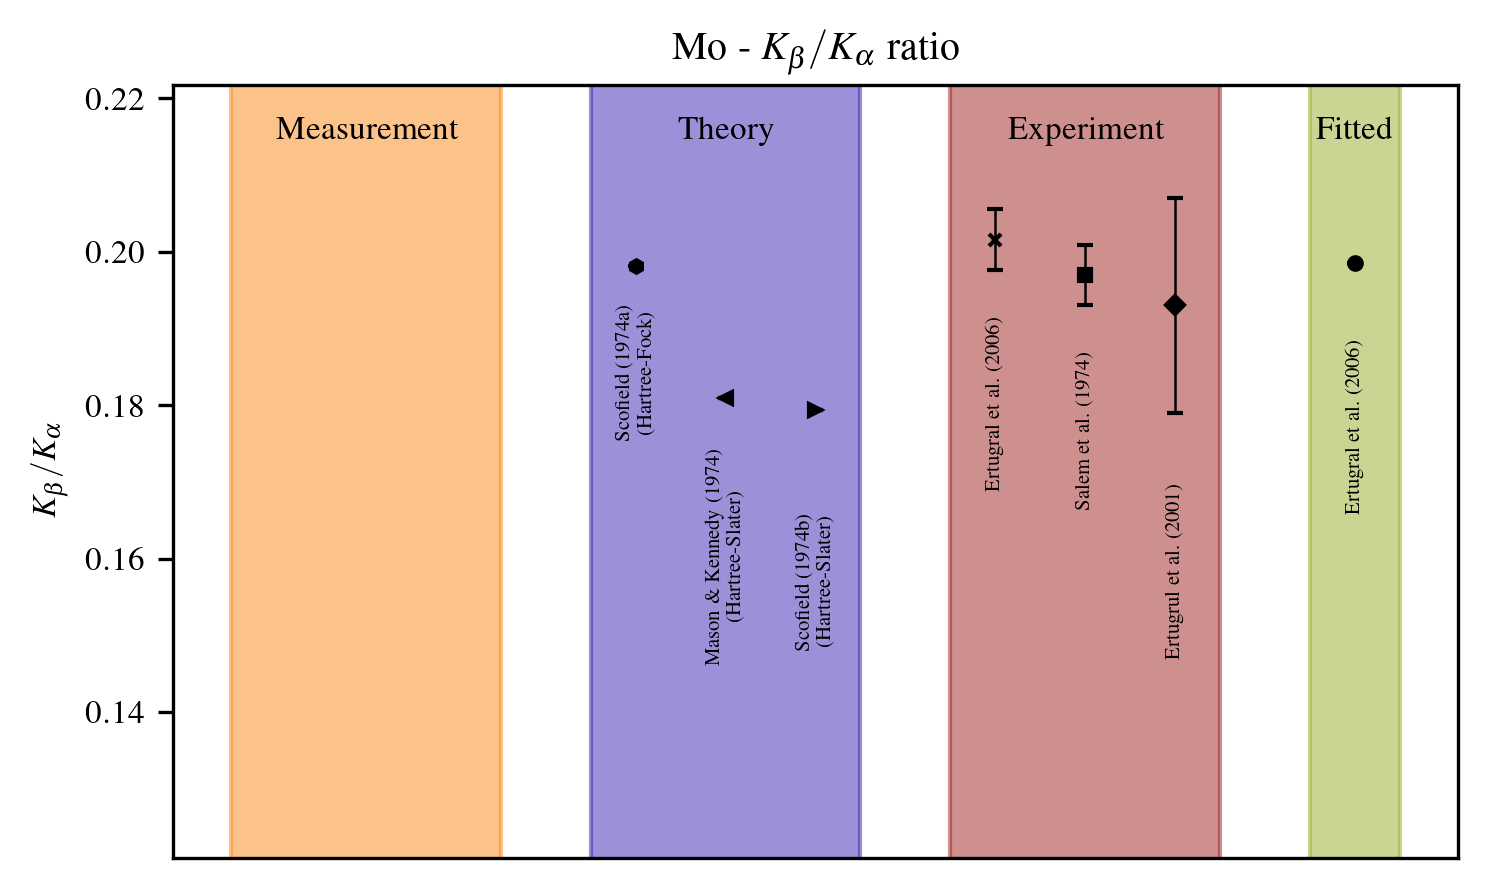

In [69]:
Kb1_Ka1_perElement('Mo', K_name, K_additions, Kb1_Ka1, Kb1_Ka1_err, K_scatter, K_x_index)
# for elem in Kb1_Ka1.keys():
#     Kb1_Ka1_perElement(elem, K_name, K_additions, Kb1_Ka1, Kb1_Ka1_err, K_scatter, K_x_index)